In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

In [3]:
# fft convolve of a ramp with dirichlet kernel
N = 1000
t = np.linspace(-np.pi, np.pi, N, endpoint=False)
x = np.linspace(-1,1, len(t), endpoint=False)
print(len(x))                                                                         
# dirichlet kernel
def dirichlet_kernel(x,n):
    x = x.copy()
    mask = x==0
    x[mask] = 1
    d = np.sin( (n+1/2)*x ) / np.sin(x/2)
    d[mask] = n*2 + 1
    return d

from scipy.special import diric

1000


In [4]:
# t = np.linspace(-np.pi, np.pi, 1000, endpoint=False)
# n = 10
# d = dirichlet_kernel(t, n)
# plt.plot(t, d)

# # d2 = diric(t*2, n)
# # plt.plot(t, d2)

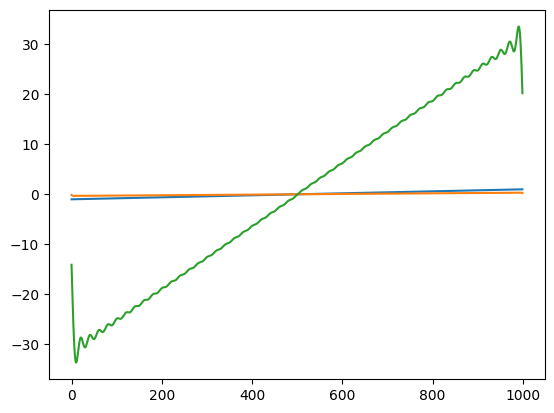

In [5]:
n = 100

d = dirichlet_kernel(t, n)
d = d/n/n*np.pi
y = fftconvolve(x, d, mode='same')

d2 = diric(t, n)*np.pi
y2 = fftconvolve(x, d2 , mode='same')
plt.plot(x)
plt.plot(y);
plt.plot(y2);

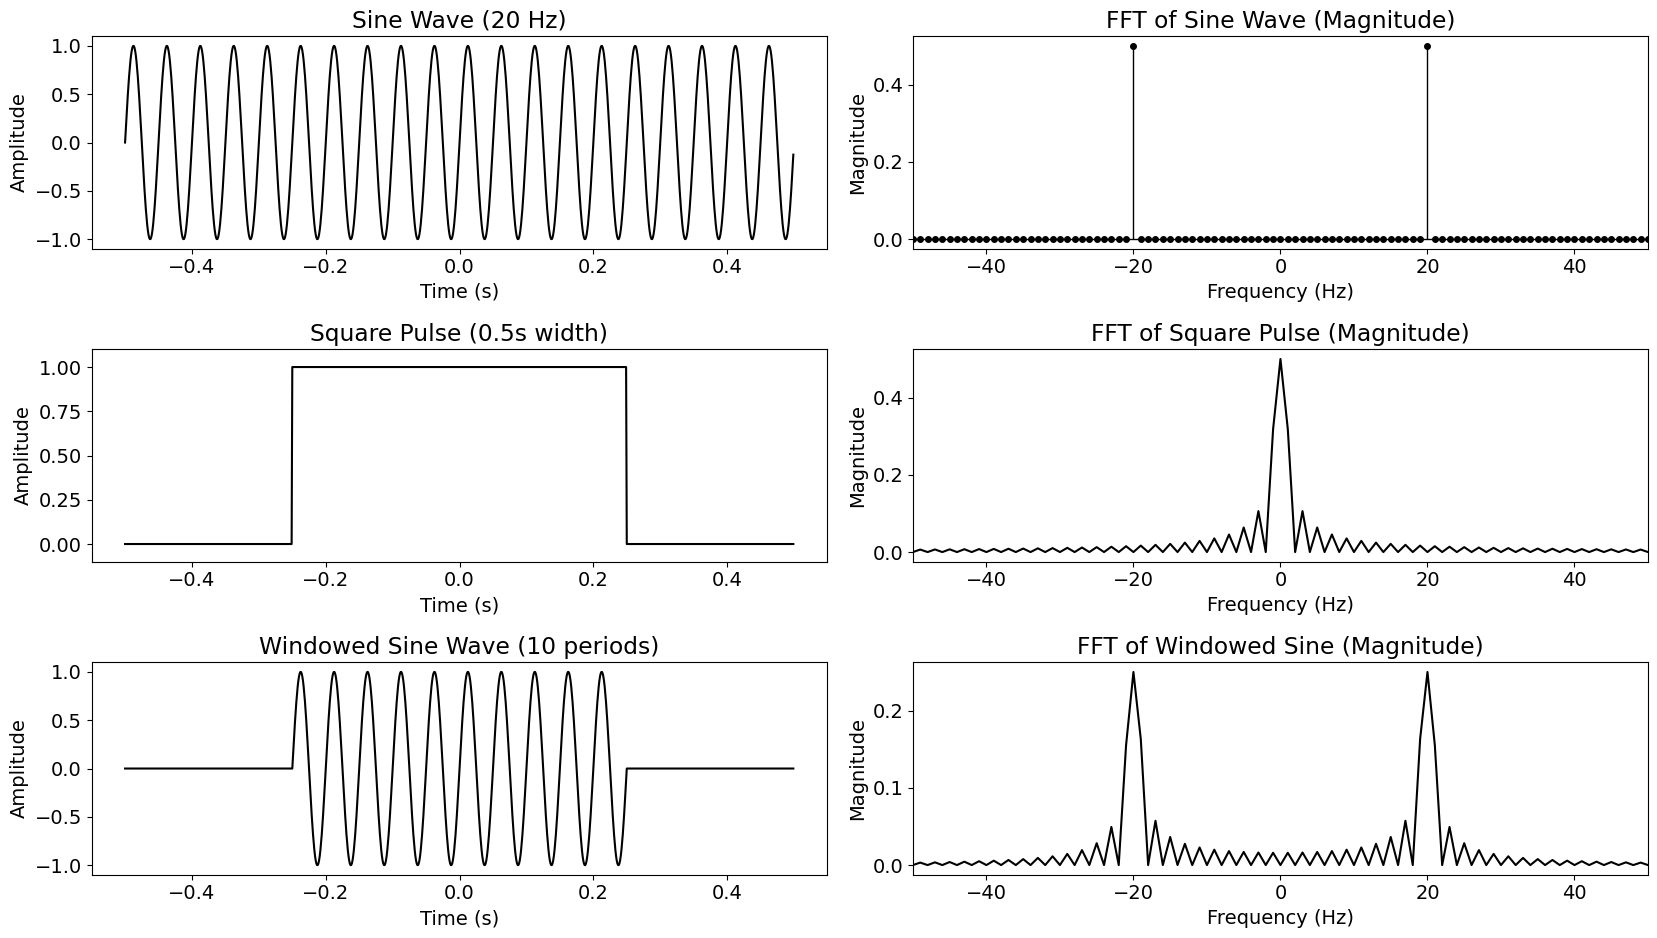

In [6]:
# Assuming necessary libraries like numpy (as np), matplotlib.pyplot (as plt),
# and numpy.fft functions (fft, fftshift, fftfreq) are imported previously.
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, fftfreq

# increase font size
plt.rcParams.update({'font.size': 14})


# Define time and frequency parameters
fs = 1000  # Sampling frequency in Hz (ensure Nyquist criterion is met for 20 Hz)
duration = 1.0  # seconds
n_points = int(fs * duration)
t = np.linspace(-duration / 2, duration / 2, n_points, endpoint=False)
f = fftshift(fftfreq(n_points, 1 / fs))

# Create the 3x2 subplot grid
fig, ax = plt.subplots(3, 2, figsize=(14*1.2, 8*1.2)) # Adjusted figsize for better layout

# --- Row 1 ---
# Col 1: Sine wave (20 Hz)
f_sine = 20  # Hz
sine_wave = np.sin(2 * np.pi * f_sine * t)
ax[0, 0].plot(t, sine_wave, color='black')
ax[0, 0].set_title('Sine Wave (20 Hz)')
ax[0, 0].set_xlabel('Time (s)')
ax[0, 0].set_ylabel('Amplitude')
ax[0, 0].grid(False)

# Col 2: FFT of Sine wave (Dirac delta representation using stem)
sine_fft = fftshift(fft(sine_wave))
sine_fft_mag = np.abs(sine_fft) / n_points # Normalize magnitude
# Use stem plot - peaks should be at +/- 20 Hz
markerline, stemlines, baseline = ax[0, 1].stem(f, sine_fft_mag, linefmt='k-', markerfmt='ko', basefmt='k-')
plt.setp(markerline, 'markersize', 4, 'color', 'black')
plt.setp(stemlines, 'color', 'black', 'linewidth', 1)
plt.setp(baseline, 'color', 'black', 'linewidth', 1)
ax[0, 1].set_title('FFT of Sine Wave (Magnitude)')
ax[0, 1].set_xlabel('Frequency (Hz)')
ax[0, 1].set_ylabel('Magnitude')
ax[0, 1].set_xlim(-50, 50) # Focus on the region around +/- 20 Hz
ax[0, 1].grid(False)


# --- Row 2 ---
# Col 1: Square pulse (0.5s width centered at 0)
pulse_width = 0.5
square_pulse = np.zeros_like(t)
square_pulse[(t >= -pulse_width / 2) & (t < pulse_width / 2)] = 1
ax[1, 0].plot(t, square_pulse, color='black')
ax[1, 0].set_title('Square Pulse (0.5s width)')
ax[1, 0].set_xlabel('Time (s)')
ax[1, 0].set_ylabel('Amplitude')
ax[1, 0].set_ylim(-0.1, 1.1) # Set y-limits for clarity
ax[1, 0].grid(False)

# Col 2: FFT of Square pulse (Sinc function shape)
square_fft = fftshift(fft(square_pulse))
square_fft_mag = np.abs(square_fft) / n_points # Normalize magnitude
ax[1, 1].plot(f, square_fft_mag, color='black')
ax[1, 1].set_title('FFT of Square Pulse (Magnitude)')
ax[1, 1].set_xlabel('Frequency (Hz)')
ax[1, 1].set_ylabel('Magnitude')
ax[1, 1].set_xlim(-50, 50) # Focus on the main lobe and side lobes
ax[1, 1].grid(False)


# --- Row 3 ---
# Col 1: Sine wave multiplied by square pulse (windowed sine)
# This results in 20 Hz * 0.5 s = 10 periods within the pulse
windowed_sine = sine_wave * square_pulse
ax[2, 0].plot(t, windowed_sine, color='black')
ax[2, 0].set_title('Windowed Sine Wave (10 periods)')
ax[2, 0].set_xlabel('Time (s)')
ax[2, 0].set_ylabel('Amplitude')
ax[2, 0].grid(False)

# Col 2: FFT of Windowed Sine wave
windowed_sine_fft = fftshift(fft(windowed_sine))
windowed_sine_fft_mag = np.abs(windowed_sine_fft) / n_points # Normalize magnitude
ax[2, 1].plot(f, windowed_sine_fft_mag, color='black')
ax[2, 1].set_title('FFT of Windowed Sine (Magnitude)')
ax[2, 1].set_xlabel('Frequency (Hz)')
ax[2, 1].set_ylabel('Magnitude')
ax[2, 1].set_xlim(-50, 50) # Focus on the convolved spectrum
ax[2, 1].grid(False)


# Adjust layout and display plot
plt.tight_layout()
plt.show()



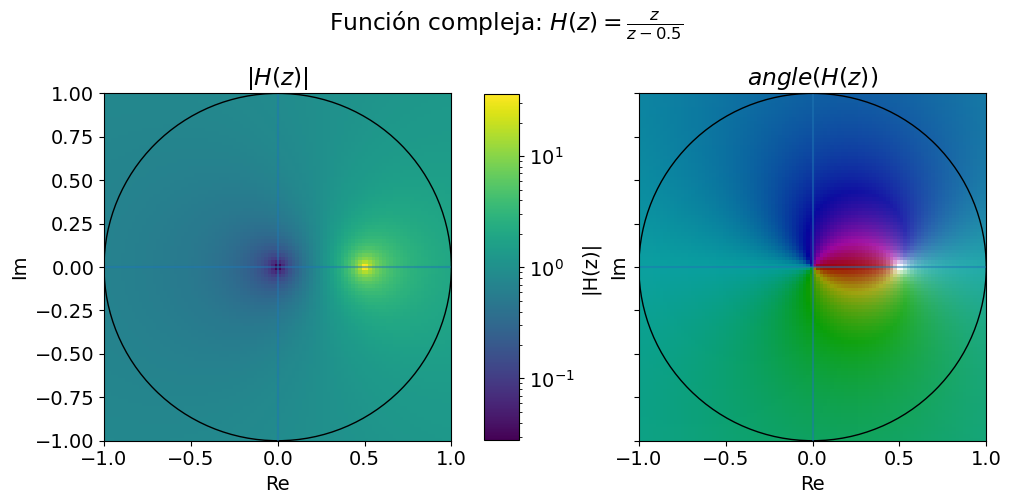

In [7]:
from matplotlib.colors import hsv_to_rgb
import matplotlib.pyplot as plt
import numpy as np
def complexfunction(func,xl,yl, mode='hsv', ax=None):
    if ax is None:
        ax = plt.gca()
    x,y = np.meshgrid(xl,yl)
    z = x + 1j*y
    H = func(z)    
    if mode == 'hsv':
        hue = (np.angle(H)+np.pi)/(2*np.pi)
        sat = np.exp(-abs(H)/abs(H).max()*4)
        val = np.exp(-sat/2)
        C = np.ones((len(xl),len(yl),3))
        C[:,:,0] = hue
        C[:,:,1] = sat
        C[:,:,2] = val
        return ax.imshow(hsv_to_rgb(C),extent= [min(xl),max(xl),min(yl),max(yl)]);
    elif mode == 'gray':
        C = abs(H)
        # log norm colormap
        from matplotlib.colors import LogNorm
        return ax.imshow(C,extent= [min(xl),max(xl),min(yl),max(yl)], norm=LogNorm());

func = lambda z: z/(z-0.5)

# subplots 2 columns
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True, layout='constrained')   
x = y = np.linspace(-5,5,500)
im = complexfunction(func, x,y, mode='gray', ax=ax[0])
fig.colorbar(im, ax=ax[0], shrink=0.8, aspect=10, label='|H(z)|')

ax[0].vlines(0,-1,1, alpha=0.5)
ax[0].hlines(0,-1,1, alpha=0.5);
# add a circle
ax[0].add_artist(plt.Circle((0,0),1,color='black',fill=False));
ax[0].set_xlim(-1,1)
ax[0].set_ylim(-1,1); 
ax[0].set_xlabel('Re')
ax[0].set_ylabel('Im');
ax[0].set_title('$|H(z)|$');

# title whole figure not axes
fig.suptitle('Función compleja: $H(z) = \\frac{z}{z-0.5}$');

complexfunction(func, x,y, mode='hsv', ax=ax[1])

ax[1].vlines(0,-1,1, alpha=0.5)
ax[1].hlines(0,-1,1, alpha=0.5);
# add a circle
ax[1].add_artist(plt.Circle((0,0),1,color='black',fill=False));
ax[1].set_xlim(-1,1)
ax[1].set_xlabel('Re')
ax[1].set_ylabel('Im');
ax[1].set_title('$angle(H(z))$');

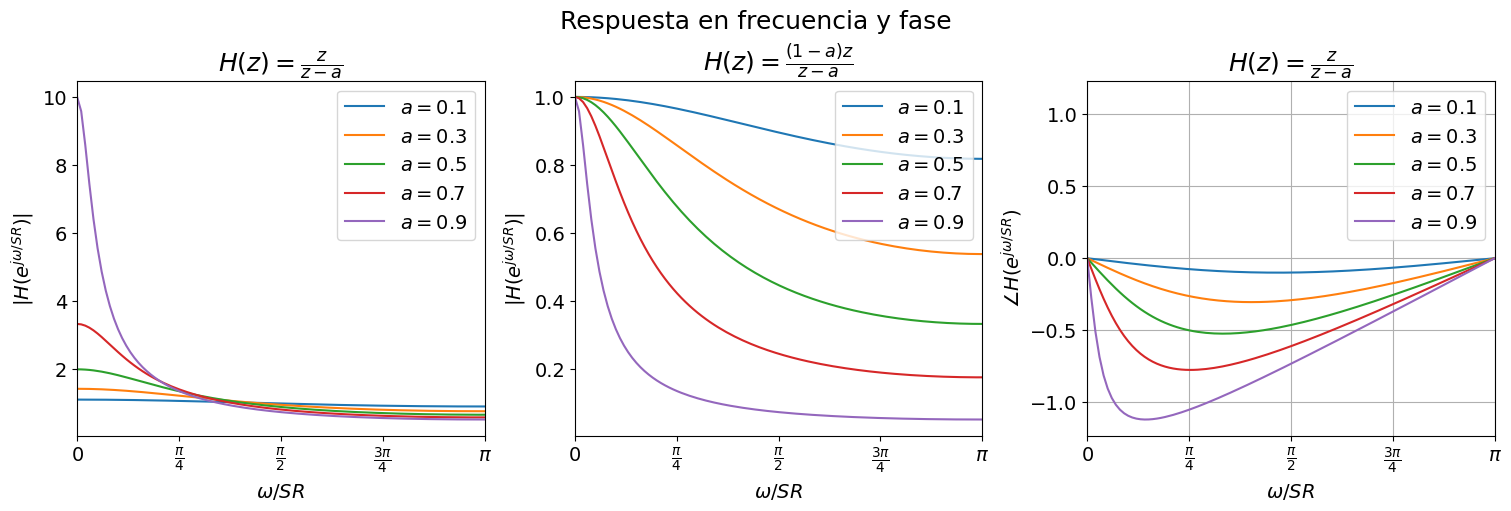

In [8]:
theta = np.linspace(0,2*np.pi,200)
z = np.exp(1j*theta)

func = lambda z,b,a: b*z/(z-a)

# two columns
fig, ax = plt.subplots(1, 3, figsize=(15, 5), layout='constrained')        
fig.suptitle('Respuesta en frecuencia y fase', fontsize=18);

for a in [0.1,0.3,0.5,0.7,0.9]:
    ax[0].plot(theta,abs(func(z,1,a)),label=f'$a={a}$');
ax[0].legend();
ax[0].set_xlabel('$\\omega/SR$')
ax[0].set_ylabel('$|H(e^{j\\omega/SR})|$');
ax[0].set_title('$H(z) = \\frac{z}{z-a}$', fontsize=18);
# xticks 0 to $\pi$ in letters
ax[0].set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi], ['$0$', '$\\frac{\\pi}{4}$', '$\\frac{\\pi}{2}$', '$\\frac{3\\pi}{4}$', '$\\pi$']);
ax[0].set_xlim(0,np.pi);


for a in [0.1,0.3,0.5,0.7,0.9]: 
    ax[1].plot(theta,abs(func(z,1-a,a)),label=f'$a={a}$');
ax[1].legend();
ax[1].set_xlabel('$\\omega/SR$')
ax[1].set_ylabel('$|H(e^{j\\omega/SR})|$');
ax[1].set_title('$H(z) = \\frac{(1-a)z}{z-a}$', fontsize=18);
# xticks 0 to $\pi$ in letters
ax[1].set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi], ['$0$', '$\\frac{\\pi}{4}$', '$\\frac{\\pi}{2}$', '$\\frac{3\\pi}{4}$', '$\\pi$']);
ax[1].set_xlim(0,np.pi);


for a in [0.1,0.3,0.5,0.7,0.9]:
    phase = np.angle(func(z,1-a,a))
    # Unwrap phase to avoid jumps
    unwrapped_phase = np.unwrap(phase)
    ax[2].plot(theta, unwrapped_phase, label=f'$a={a}$');
ax[2].legend();
ax[2].set_xlabel('$\\omega/SR$')
ax[2].set_ylabel('$\\angle H(e^{j\\omega/SR})$');
ax[2].set_title('$H(z) = \\frac{z}{z-a}$', fontsize=18);
# xticks 0 to $\pi$ in letters
ax[2].set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi], ['$0$', '$\\frac{\\pi}{4}$', '$\\frac{\\pi}{2}$', '$\\frac{3\\pi}{4}$', '$\\pi$']);
ax[2].set_xlim(0,np.pi);
ax[2].grid(True)


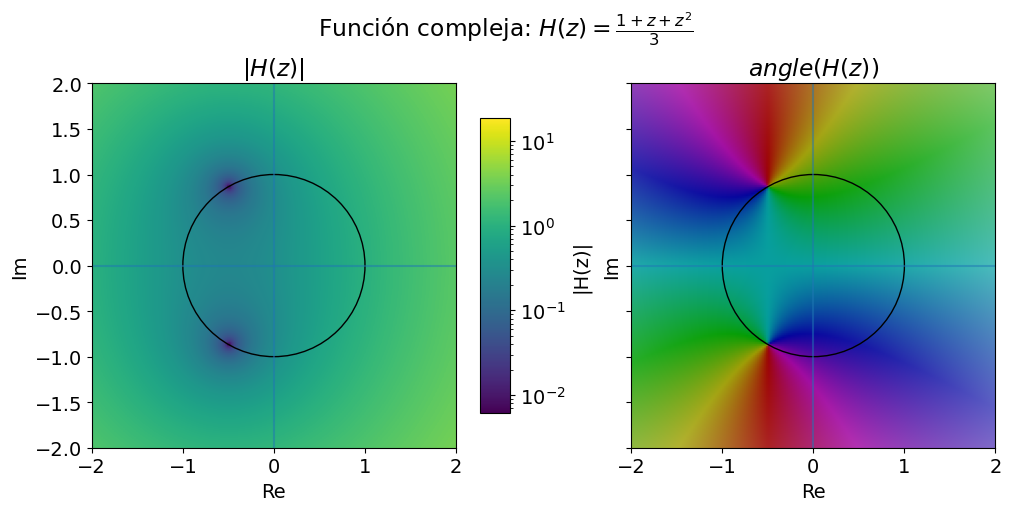

In [9]:
from matplotlib.colors import hsv_to_rgb
import matplotlib.pyplot as plt
import numpy as np

a = 1
func2 = lambda z,b0,b1,b2: (b0 + b1*z + b2*z**2)/(b0+b1+b2)
func = lambda z: func2(z,a,1.0,a)

# subplots 2 columns
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True, layout='constrained')   
x = y = np.linspace(-5,5,500)
im = complexfunction(func, x,y, mode='gray', ax=ax[0])
fig.colorbar(im, ax=ax[0], shrink=0.8, aspect=10, label='|H(z)|')

ax[0].vlines(0,-2,2, alpha=0.5)
ax[0].hlines(0,-2,2, alpha=0.5);
# add a circle
ax[0].add_artist(plt.Circle((0,0),1,color='black',fill=False));
ax[0].set_xlim(-2,2)
ax[0].set_ylim(-2,2); 
ax[0].set_xlabel('Re')
ax[0].set_ylabel('Im');
ax[0].set_title('$|H(z)|$');

# title whole figure not axes
fig.suptitle('Función compleja: $H(z) = \\frac{1 + z + z^2}{3}$');

complexfunction(func, x,y, mode='hsv', ax=ax[1])

ax[1].vlines(0,-2,2, alpha=0.5)
ax[1].hlines(0,-2,2, alpha=0.5);
# add a circle
ax[1].add_artist(plt.Circle((0,0),1,color='black',fill=False));
ax[1].set_xlim(-2,2)
ax[1].set_xlabel('Re')
ax[1].set_ylabel('Im');
ax[1].set_title('$angle(H(z))$');

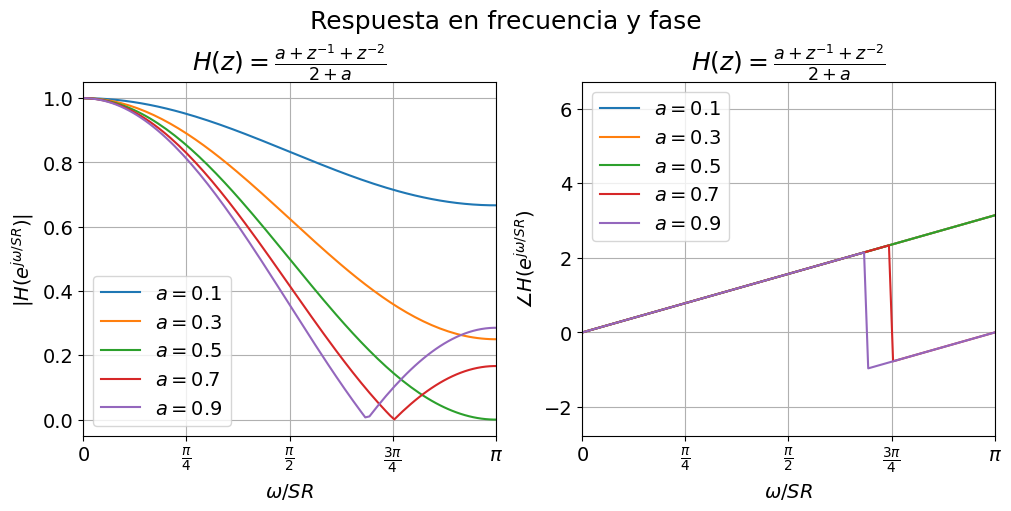

In [10]:


# Now FIR filter analysis
fig, ax = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')
fig.suptitle('Respuesta en frecuencia y fase', fontsize=18);

# def func2 2nd order FIR filter
func2 = lambda z,b0,b1,b2: (b0 + b1*z + b2*z**2)/(b0+b1+b2)

for a in [0.1,0.3,0.5,0.7,0.9]:
    H = func2(z,a,1,a)
    phase = np.angle(H)
    # Unwrap phase to avoid jumps
    unwrapped_phase = np.unwrap(phase)
    ax[0].plot(theta, abs(H), label=f'$a={a}$');
    ax[1].plot(theta, unwrapped_phase, label=f'$a={a}$');

ax[0].legend();
ax[0].set_xlabel('$\\omega/SR$')
ax[0].set_ylabel('$|H(e^{j\\omega/SR})|$');
ax[0].set_title('$H(z) = \\frac{a + z^{-1} + z^{-2}}{2+a}$', fontsize=18);
# xticks 0 to $\pi$ in letters
ax[0].set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi], ['$0$', '$\\frac{\\pi}{4}$', '$\\frac{\\pi}{2}$', '$\\frac{3\\pi}{4}$', '$\\pi$']);
ax[0].set_xlim(0,np.pi);
ax[0].grid(True)

ax[1].legend();
ax[1].set_xlabel('$\\omega/SR$')
ax[1].set_ylabel('$\\angle H(e^{j\\omega/SR})$');
ax[1].set_title('$H(z) = \\frac{a + z^{-1} + z^{-2}}{2+a}$', fontsize=18);
# xticks 0 to $\pi$ in letters
ax[1].set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi], ['$0$', '$\\frac{\\pi}{4}$', '$\\frac{\\pi}{2}$', '$\\frac{3\\pi}{4}$', '$\\pi$']);
ax[1].set_xlim(0,np.pi);
ax[1].grid(True)

plt.show()



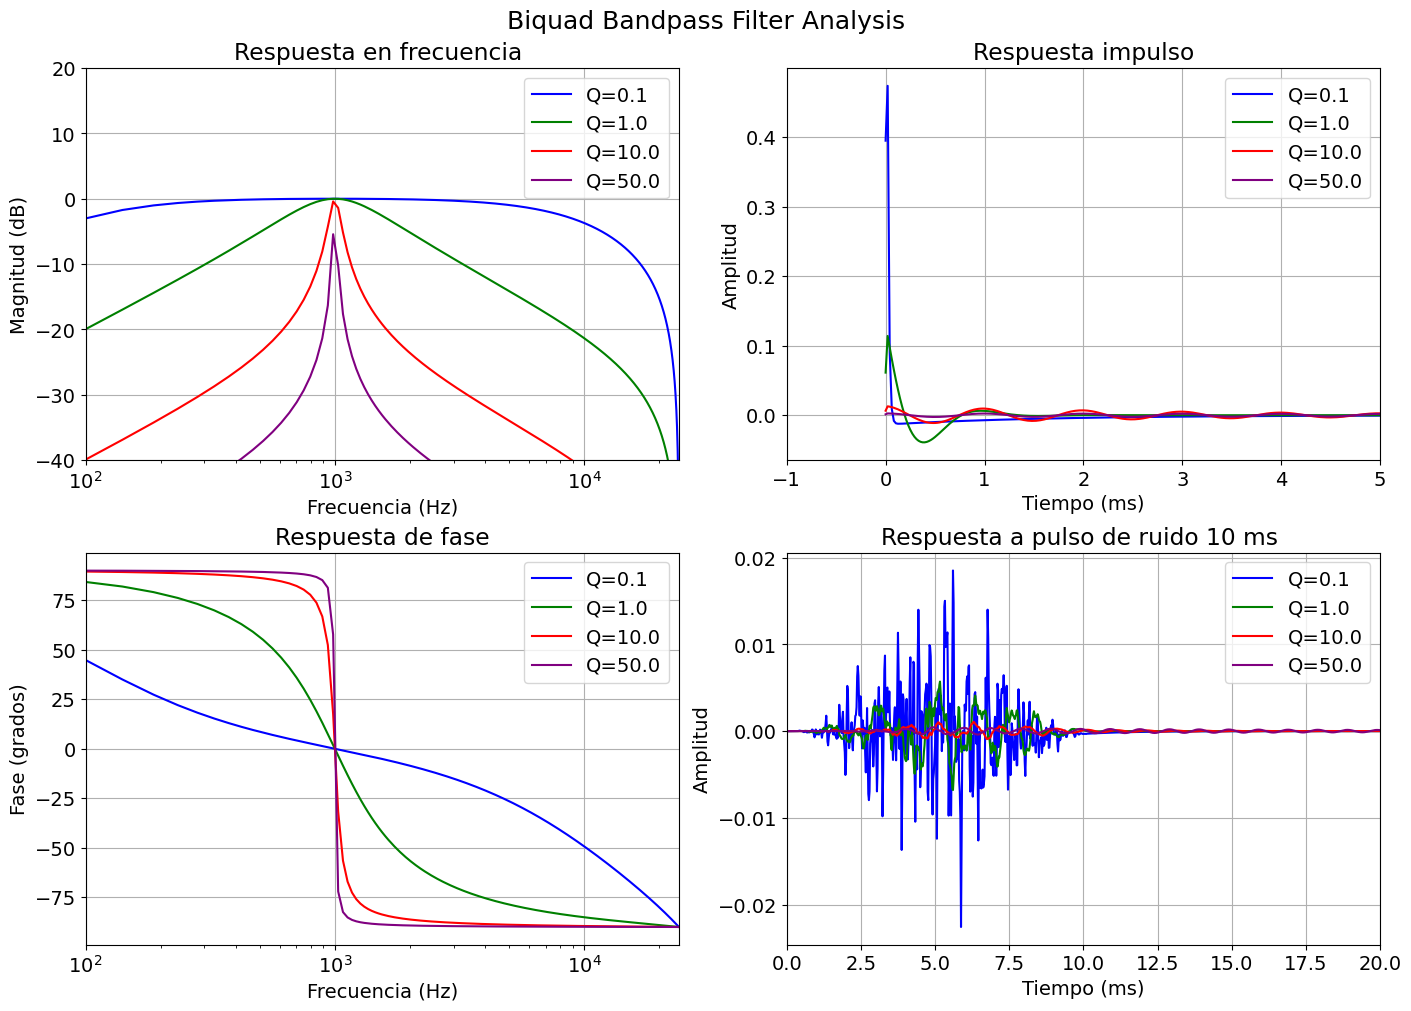

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz, lfilter
from scipy.signal.windows import tukey
# Create a 2x2 subplot for biquad bandpass filter analysis
fig, ax = plt.subplots(2, 2, figsize=(14, 10), layout='constrained')
fig.suptitle('Biquad Bandpass Filter Analysis', fontsize=18)

# Frequency for analysis
sr = 48000  # Sample rate

# Center frequency
fc = 1000  # Hz
w0 = 2 * np.pi * fc / sr  # Normalized center frequency

# Different Q values to analyze
Q_values = [0.1, 1.0, 10.0, 50.0]
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Calculate frequency responses
for i, Q in enumerate(Q_values):
    # Biquad bandpass filter coefficients
    alpha = np.sin(w0) / (2 * Q)
    
    # Filter coefficients (Direct Form I)
    b0 = alpha
    b1 = 0
    b2 = -alpha
    a0 = 1 + alpha
    a1 = -2 * np.cos(w0)
    a2 = 1 - alpha
    
    # Normalize by a0
    b0 /= a0
    b1 /= a0
    b2 /= a0
    a1 /= a0
    a2 /= a0
    a0 = 1.0
    
    # Calculate frequency response scipy freqz

    f, H = freqz([b0, b1, b2], [a0, a1, a2], fs=sr)
    
    # Magnitude response (top-left)
    ax[0, 0].plot(f, 20 * np.log10(np.abs(H) + 1e-10), color=colors[i], label=f'Q={Q}')
    
    # Phase response (bottom-left)
    ax[1, 0].plot(f, np.unwrap(np.angle(H)) * 180 / np.pi, color=colors[i], label=f'Q={Q}')
    
    # Calculate impulse response
    delta = np.zeros(int(0.02 * sr))  # 20 ms impulse
    delta[0] = 1.0  # Impulse input
    y = lfilter([b0, b1, b2], [a0, a1, a2], delta)
    
    time = np.arange(len(delta)) / sr * 1000  # Convert to milliseconds
    
    # Impulse response (top-right)
    ax[0, 1].plot(time, y, color=colors[i], label=f'Q={Q}')
    
    # Calculate response to short noise pulse with tukeywindow
    
    dur = 0.01  # Duration of the pulse in seconds
    s0 = 10
    s1 = s0 + int(dur * sr)  # End of the pulse
    pulse = np.zeros(int(dur * sr)*100) 
    pulse[s0:s1] = tukey(s1-s0, 1.0)*np.random.randn(s1-s0)*0.01
    pulse = pulse - np.mean(pulse)  # Remove DC component
    
    y = lfilter([b0, b1, b2], [a0, a1, a2], pulse)
    time = np.arange(len(pulse)) / sr * 1000  # Convert to milliseconds

    # Impulse response  (bottom-right)
    ax[1, 1].plot(time, y, color=colors[i], label=f'Q={Q}')

# Configure plots
ax[0, 0].set_title('Respuesta en frecuencia ')
ax[0, 0].set_xlabel('Frecuencia (Hz)')
ax[0, 0].set_ylabel('Magnitud (dB)')
ax[0, 0].set_xscale('log')
ax[0, 0].set_xlim(100, sr/2)
ax[0, 0].set_ylim(-40, 20)
ax[0, 0].grid(True)
ax[0, 0].legend()

ax[1, 0].set_title('Respuesta de fase')
ax[1, 0].set_xlabel('Frecuencia (Hz)')
ax[1, 0].set_ylabel('Fase (grados)')
ax[1, 0].set_xscale('log')
ax[1, 0].set_xlim(100, fs/2)
ax[1, 0].grid(True)
ax[1, 0].legend()

ax[0, 1].set_title('Respuesta impulso')
ax[0, 1].set_xlabel('Tiempo (ms)')
ax[0, 1].set_ylabel('Amplitud')
# ax[0, 1].set_ylim(-1, 1)
ax[0, 1].set_xlim(-1, 5)
ax[0, 1].grid(True)
ax[0, 1].legend()

ax[1, 1].set_title('Respuesta a pulso de ruido 10 ms ')
ax[1, 1].set_xlabel('Tiempo (ms)')
ax[1, 1].set_ylabel('Amplitud')
# ax[1, 1].set_ylim(-1, 1)
ax[1, 1].set_xlim(0, 20)
ax[1, 1].grid(True)
ax[1, 1].legend()

plt.show()

752
85
8
2


/tmp/ipykernel_94227/698718770.py:112: UserWarning: The figure layout has changed to tight
  plt.tight_layout();


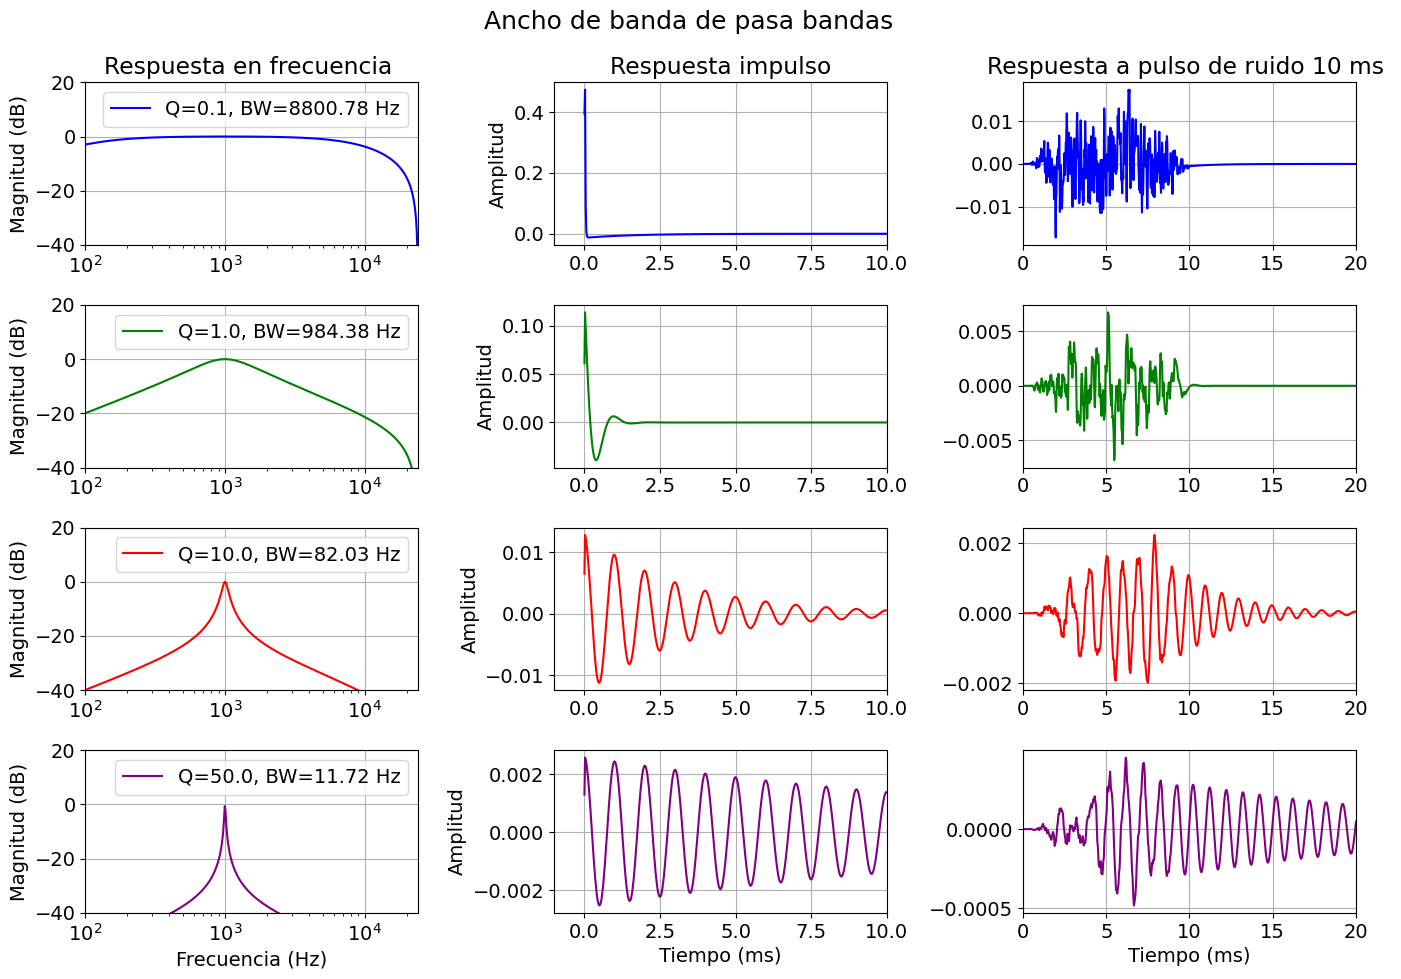

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz, lfilter
from scipy.signal.windows import tukey
# Create a 4x3 subplot for biquad bandpass filter analysis
fig, ax = plt.subplots(4, 3, figsize=(14, 10), layout='constrained')
fig.suptitle('Ancho de banda de pasa bandas', fontsize=18)

# Frequency for analysis
sr = 48000  # Sample rate

# Center frequency
fc = 1000  # Hz
w0 = 2 * np.pi * fc / sr  # Normalized center frequency

# Different Q values to analyze
Q_values = [0.1, 1.0, 10.0, 50.0]
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Calculate frequency responses
for i, Q in enumerate(Q_values):
    # Biquad bandpass filter coefficients
    alpha = np.sin(w0) / (2 * Q)    
    
    # Filter coefficients (Direct Form I)
    b0 = alpha
    b1 = 0
    b2 = -alpha
    a0 = 1 + alpha
    a1 = -2 * np.cos(w0)
    a2 = 1 - alpha
    
    # Normalize by a0
    b0 /= a0
    b1 /= a0
    b2 /= a0
    a1 /= a0
    a2 /= a0
    a0 = 1.0
    
    # Calculate frequency response scipy freqz

    f, H = freqz([b0, b1, b2], [a0, a1, a2], fs=sr, worN=2048)

    # Compute BW intersecting H in -3dB
    H_db = 20 * np.log10(np.abs(H) + 1e-10)
    H_db = H_db - np.max(H_db)  # Normalize to 0 dB 
    bw = np.where(H_db > -3)[0]
    print(len(bw))
    bw = f[bw]
    bw = bw[-1] - bw[0]  # Bandwidth in Hz
    
    # Magnitude response (top-left)
    ax[i, 0].plot(f, 20 * np.log10(np.abs(H) + 1e-10), color=colors[i], label=f'Q={Q}, BW={bw:.2f} Hz')
    
    # Calculate impulse response
    delta = np.zeros(int(0.02 * sr))  # 20 ms impulse
    delta[0] = 1.0  # Impulse input
    y = lfilter([b0, b1, b2], [a0, a1, a2], delta)
    
    time = np.arange(len(delta)) / sr * 1000  # Convert to milliseconds
    
    # Impulse response (top-right)
    ax[i, 1].plot(time, y, color=colors[i], label=f'Q={Q}, BW={bw:.2f} Hz')
    
    # Calculate response to short noise pulse with tukeywindow
    
    dur = 0.01  # Duration of the pulse in seconds
    s0 = 10
    s1 = s0 + int(dur * sr)  # End of the pulse
    pulse = np.zeros(int(dur * sr)*100) 
    pulse[s0:s1] = tukey(s1-s0, 0.5)*np.random.randn(s1-s0)*0.01
    pulse = pulse - np.mean(pulse)  # Remove DC component
    
    y = lfilter([b0, b1, b2], [a0, a1, a2], pulse)
    time = np.arange(len(pulse)) / sr * 1000  # Convert to milliseconds

    # Impulse response  (bottom-right)
    ax[i, 2].plot(time, y, color=colors[i], label=f'Q={Q}, BW={bw:.2f} Hz')

    # Configure plots

    if i == 0:
        ax[i, 0].set_title('Respuesta en frecuencia ')
    if i == 3:
        ax[i, 0].set_xlabel('Frecuencia (Hz)')
    ax[i, 0].set_ylabel('Magnitud (dB)')
    ax[i, 0].set_xscale('log')
    ax[i, 0].set_xlim(100, sr/2)
    ax[i, 0].set_ylim(-40, 20)
    ax[i, 0].grid(True)
    ax[i, 0].legend()

    if i == 0:
        ax[i, 1].set_title('Respuesta impulso')
    if i == 3:
        ax[i, 1].set_xlabel('Tiempo (ms)')
    ax[i, 1].set_ylabel('Amplitud')
    ax[i, 1].set_xlim(-1, 10)
    ax[i, 1].grid(True)
    # ax[i, 1].legend()

    if i ==0:   
        ax[i, 2].set_title('Respuesta a pulso de ruido 10 ms ')
    if i == 3:  
        ax[i, 2].set_xlabel('Tiempo (ms)')
    # ax[i, 2].set_ylabel('Amplitud')
    ax[i, 2].set_xlim(0, 20)
    ax[i, 2].grid(True)
    # ax[i, 2].legend()

plt.tight_layout();
plt.show()

/tmp/ipykernel_94227/1710925376.py:51: UserWarning: The figure layout has changed to tight
  plt.tight_layout();


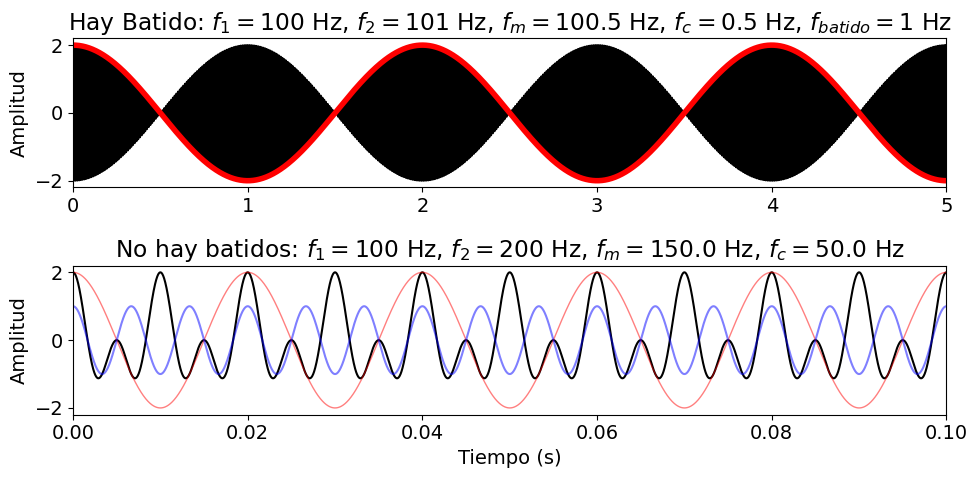

In [118]:
# 2 row plot. First beats fenomena f1=100, f2=101. Second row, f1=100, f2=200

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

fig, ax = plt.subplots(2, 1, figsize=(10, 5), layout='constrained')
# fig.suptitle('Fenómeno de batido', fontsize=18)
# Frequency for analysis
sr = 48000  # Sample rate
# Center frequency
f1 = 100  # Hz
f2 = 101  # Hz
fm = (f1 + f2) / 2
fc = (f2 - f1) / 2
t  = np.arange(0, 5, 1/sr)
x = np.cos(2 * np.pi * f1 * t) + np.cos(2 * np.pi * f2 * t)
env = np.cos(2 * np.pi * (f1-f2)/2 * t)*2
ax[0].plot(t, x, color='black')
ax[0].plot(t, env, color='red', alpha=1,lw=4)
batido = "{batido}"
ax[0].set_title(f'Hay Batido: $f_1={f1}$ Hz, $f_2={f2}$ Hz, $f_m={fm}$ Hz, $f_c={fc}$ Hz, $f_{batido}={f2-f1}$ Hz')
# ax[0].set_xlabel('Tiempo (s)')
ax[0].set_ylabel('Amplitud')
ax[0].set_xlim(0, 5)

# save audio soundfile
import soundfile as sf
sf.write('batido.wav', x, sr)
display(Audio(x, rate=sr))

f1= 100  # Hz
f2 = 200  # Hz
fm = (f1 + f2) / 2
fc = (f2 - f1) / 2

t  = np.arange(0, 5, 1/sr)
x = np.cos(2 * np.pi * f1 * t) + np.cos(2 * np.pi * f2 * t)
env = np.cos(2 * np.pi * (f1-f2)/2 * t)*2
carrier = np.cos(2 * np.pi * (f1 + f2) / 2 * t)
ax[1].plot(t, x, color='black')

ax[1].plot(t, env, color='red', alpha=0.5,lw=1)
ax[1].plot(t, carrier, color='blue', alpha=0.5)
# ax[1].plot(t, env*carrier, color='green', alpha=0.5)

ax[1].set_title(f'No hay batidos: $f_1={f1}$ Hz, $f_2={f2}$ Hz, $f_m={fm}$ Hz, $f_c={fc}$ Hz')
ax[1].set_xlabel('Tiempo (s)')
ax[1].set_ylabel('Amplitud')
ax[1].set_xlim(0, 0.1)
plt.tight_layout();

sf.write('no_batido.wav', x, sr)
display(Audio(x, rate=sr))